In [2]:
import numpy as np
import pandas as pd
import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 
import featuretools as ft


In [3]:
with open("../data/german-credit-R.arff", "r") as file:
    data = arff.load(file)
df = pd.DataFrame(data["data"], columns=[attr[0] for attr in data["attributes"]])
 

In [4]:
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose","Risk"]
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [5]:
df.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [6]:
from sklearn.metrics import accuracy_score, precision_score

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary') 
    confusion_mx = confusion_matrix(y_test, y_pred)
    
    return accuracy, precision,confusion_mx

In [7]:
X = df.drop(columns=["Risk"])  
y = df["Risk"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression()
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)

In [9]:
logreg_accuracy, logreg_precision,logreg_confusion_mx = evaluate_classifier(logreg, X_train, y_train, X_test, y_test)
nb_accuracy, nb_precision,nb_confusion_mx = evaluate_classifier(nb, X_train, y_train, X_test, y_test)
rf_accuracy, rf_precision,rf_confusion_mx = evaluate_classifier(rf, X_train, y_train, X_test, y_test)

print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}, Precision: {logreg_precision:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}, Precision: {nb_precision:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}\n\n")

print(f"Logistic Regression Confusion Matrix:\n{logreg_confusion_mx}")
print(f"Naive Bayes Confusion Matrix:\n{nb_confusion_mx}")
print(f"Random Forest Confusion Matrix:\n{rf_confusion_mx}")

Logistic Regression Accuracy: 0.7550, Precision: 0.7771
Naive Bayes Accuracy: 0.7100, Precision: 0.7610
Random Forest Accuracy: 0.7700, Precision: 0.7950


Logistic Regression Confusion Matrix:
[[ 22  37]
 [ 12 129]]
Naive Bayes Confusion Matrix:
[[ 21  38]
 [ 20 121]]
Random Forest Confusion Matrix:
[[ 26  33]
 [ 13 128]]


In [10]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9
af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x000,x001,x002,x003,x004,x005,x006,x007,x008,x004*exp(x007),x007*exp(x003),x004*exp(x003),x005/x002,x005**3*exp(x007),Abs(x006),x005**3*x006,x003**2/x002,1/(x004*x008),x000*exp(x003),Abs(x003)*Abs(x006)
0,2.414647,0.670280,0.146949,-0.133710,-0.699707,-1.254566,1.263499,3.243815,-1.455632,-17.934414,2.837830,-0.612134,-8.537412,-50.611724,1.263499,-2.494911,0.121664,0.981821,2.112438,0.168943
1,-0.223927,0.670280,0.146949,1.749535,-0.699707,0.336513,-0.337522,0.008048,0.061705,-0.705361,0.046291,-4.024666,2.289997,0.038415,0.337522,-0.012862,20.829474,-23.161315,-1.288012,0.590506
2,1.271265,0.670280,0.146949,1.749535,0.566731,1.132053,-0.721384,-1.236478,-0.949853,0.164582,-7.112134,3.259797,7.703701,0.421312,0.721384,-1.046565,20.829474,-1.857662,7.312226,1.262086
3,-0.575737,-1.491914,0.146949,-0.133710,1.833169,1.132053,0.613804,0.008048,-0.949853,1.847982,0.007041,1.603736,7.703701,1.462497,0.613804,0.890492,0.121664,-0.574303,-0.503679,0.082072
4,-1.279356,-1.491914,0.146949,-0.133710,1.833169,1.132053,-0.845439,-0.738668,1.073263,0.875797,-0.646218,1.603736,7.703701,0.693107,0.845439,-1.226541,0.121664,0.508266,-1.119236,0.113044


In [11]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")

Nombre de nouvelles features créées : 11


In [12]:
acc_logreg_af, prec_logreg_af,confusion_mx_logreg_af = evaluate_classifier(logreg, X_train_af, y_train, X_test_af, y_test)
acc_nb_af, prec_nb_af,confusion_mx_nb_af = evaluate_classifier(nb, X_train_af, y_train, X_test_af, y_test)
acc_rf_af, prec_rf_af,confusion_mx_rf_af = evaluate_classifier(rf, X_train_af, y_train, X_test_af, y_test)

print(f"Logistic Regression Accuracy with AutoFeat: {acc_logreg_af:.2f}, Precision: {prec_logreg_af:.2f}")
print(f"Naive Bayes Accuracy with AutoFeat: {acc_nb_af:.2f}, Precision: {prec_nb_af:.2f}")
print(f"Random Forest Accuracy with AutoFeat: {acc_rf_af:.2f}, Precision: {prec_rf_af:.2f}\n\n")

print(f"Logistic Regression Confusion Matrix with AutoFeat:\n{confusion_mx_logreg_af}")
print(f"Naive Bayes Confusion Matrix with AutoFeat:\n{confusion_mx_nb_af}")
print(f"Random Forest Confusion Matrix with AutoFeat:\n{confusion_mx_rf_af}")

Logistic Regression Accuracy with AutoFeat: 0.76, Precision: 0.78
Naive Bayes Accuracy with AutoFeat: 0.71, Precision: 0.76
Random Forest Accuracy with AutoFeat: 0.74, Precision: 0.79


Logistic Regression Confusion Matrix with AutoFeat:
[[ 21  38]
 [ 10 131]]
Naive Bayes Confusion Matrix with AutoFeat:
[[ 22  37]
 [ 21 120]]
Random Forest Confusion Matrix with AutoFeat:
[[ 26  33]
 [ 18 123]]


In [13]:
import featuretools as ft

es = ft.EntitySet(id = 'gc')

es.add_dataframe(dataframe_name = 'germancredit', dataframe = df, index = 'index')

feature_matrix, feature_names = ft.dfs(entityset=es, 
target_dataframe_name = 'germancredit', 
max_depth = 2, 
verbose = 1, 
n_jobs = 1)
feature_matrix.head()

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\entityset\entityset.py:1733: UserWarning: index index not found in dataframe, creating new integer column
  warnings.warn(
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\featuretools\synthesis\deep_feature_synthesis.py:169: UserWarning: Only one dataframe in entityset, changing max_depth to 1 since deeper features cannot be created
  warnings.warn(


Built 10 features
Elapsed: 00:00 | Progress: 100%|██████████


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
index,,,,,,,,,,
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0


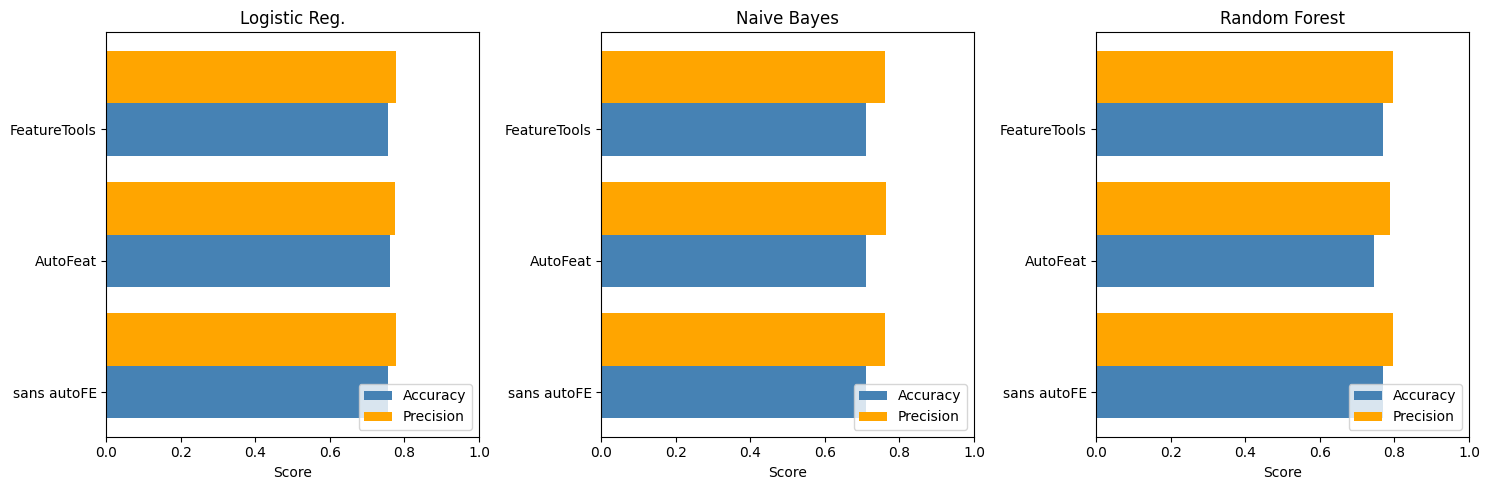

In [19]:
import matplotlib.pyplot as plt
import numpy as np

model_labels = [
    "Logistic Reg.", "Naive Bayes", "Random Forest"
]

accuracy_values = [
    [logreg_accuracy, acc_logreg_af, logreg_accuracy], 
    [nb_accuracy, acc_nb_af, nb_accuracy], 
    [rf_accuracy, acc_rf_af, rf_accuracy]
]
precision_values = [
    [logreg_precision, prec_logreg_af, logreg_precision], 
    [nb_precision, prec_nb_af, nb_precision], 
    [rf_precision, prec_rf_af, rf_precision]
]

fig, axs = plt.subplots(1, len(model_labels), figsize=(15, 5))

for i, ax in enumerate(axs):
    ax.barh([0, 1, 2], accuracy_values[i], height=0.4, color='steelblue', label='Accuracy', align='center')
    ax.barh([0.4, 1.4, 2.4], precision_values[i], height=0.4, color='orange', label='Precision', align='center')

    ax.set_xlim(0, 1)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['sans autoFE', 'AutoFeat', 'FeatureTools'])
    ax.set_title(f"{model_labels[i]}")
    ax.set_xlabel("Score")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [15]:
#https://www.analyticsvidhya.com/blog/2018/08/guide-automated-feature-engineering-featuretools-python/
#https://ranasinghiitkgp.medium.com/feature-engineering-using-featuretools-with-code-10f8c83e5f68
#Avec featuretools

